# 02 — Baselines & Global Performance

**Question.** How much does each learned model actually improve over simple
temporal baselines?

Two baselines, computed on **raw observations** (no normalisation round trip),
on exactly the test samples the models saw:

* **persistence**: x̂(t+h) = x(t) — the last observation carried forward.
* **24h-lag**: x̂(t+h) = x(t+h−24h) — same clock time yesterday. *Not* a
  long-term climatology; it carries yesterday's weather, including yesterday's
  storms. Roughly flat in lead time because it carries the diurnal cycle.

They fail in opposite directions: persistence is near-perfect at short lead and
decays; the 24h-lag is lead-independent. A model that beats persistence at +6h
but not the 24h-lag has not learned the diurnal cycle; the reverse means it
tracks the current state but not the daily rhythm.

Δ=0 is **reconstruction, not forecasting** (the target is an input for visible
stations) and is excluded from all forecast averages; it appears only in the
lead curves for completeness.

In [1]:
# ── Bootstrap ────────────────────────────────────────────────────────────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
for _cand in (os.getcwd(),
              os.path.join(os.getcwd(), "notebooks", "analysis"),
              os.path.dirname(os.path.abspath("__file__"))):
    if os.path.isfile(os.path.join(_cand, "common.py")):
        if _cand not in sys.path: sys.path.insert(0, _cand)
        break
import importlib
import common as C
# common.py is edited while these notebooks are open. A plain import is cached
# by the kernel, so edits are invisible until a restart — and a stale module
# silently serves stale caches (this is exactly how a station_table without
# easting/northing survived a fix to station_table). Reload every run.
importlib.reload(C)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
RUNS = C.discovered_runs()
for r, d in RUNS.items(): print(f"{r:20s} {sorted(d)}")

lstm-baseline-v1     ['mr0.00']
v27                  ['mr0.00', 'mr0.50']
v30-nll              ['mr0.00', 'mr0.50']
v31                  ['mr0.00']
v32-blind            ['mr0.00']


## 1. Aggregation pass (heavy — ~2-4 min per dump on first run, then cached)

One streaming pass per dump accumulates error sums/counts at
(lead × station × variable) for the model AND both baselines, on each
estimator's own valid set, with all exclusions applied. Cached under
`analysis_outputs/cache/`.

In [2]:
PAIRS = [(r, mr) for r, mrs in RUNS.items() for mr in sorted(mrs)]
AGG = {}
for run, mr in PAIRS:
    AGG[(run, mr)] = C.load_agg(run, mr)
    print(f"  aggregated {run:20s} {mr}")
GRID = AGG[PAIRS[0]]["grid"]
LEAD = C.lead_labels(GRID)
K = len(GRID); KF = slice(1, None)          # forecast leads (Δ>0)
MR0 = [(r, "mr0.00") for r in RUNS if "mr0.00" in RUNS[r]]
print("\nleads:", LEAD)

  aggregated lstm-baseline-v1     mr0.00
  aggregated v27                  mr0.00
  aggregated v27                  mr0.50
  aggregated v30-nll              mr0.00
  aggregated v30-nll              mr0.50
  aggregated v31                  mr0.00
  aggregated v32-blind            mr0.00

leads: ['t=0', '+30min', '+1h', '+1h30', '+2h', '+2h30', '+3h', '+3h30', '+4h', '+4h30', '+5h', '+5h30', '+6h']


## 2. Headline table — MAE (Δ>0), physical units, with skill vs both baselines

All models at **mr0.00** (all stations visible): the only regime every model
supports, and the one the LSTM is comparable in. Skill = 1 − MAE_model/MAE_ref;
positive beats the reference. Baselines are computed once (they are
model-independent; tiny count differences across dumps are impossible because
targets are bit-identical — audited in 01).

In [3]:
ref = AGG[("v27", "mr0.00")]
VARS = C.norm_stats()["var_names"]
rows = {}
for run, mr in MR0:
    a = AGG[(run, mr)]
    mae_kv  = C.metric(a, "mae",  pool=("N",))
    rmse_kv = C.metric(a, "rmse", pool=("N",))
    per_kv  = C.metric(ref, "mae", est="per",  pool=("N",))
    cli_kv  = C.metric(ref, "mae", est="clim", pool=("N",))
    for vi, v in enumerate(VARS):
        m  = np.average(mae_kv[KF, vi],
                        weights=a["mod_all_cnt"].sum(1)[KF, vi])
        p  = np.average(per_kv[KF, vi],
                        weights=ref["per_all_cnt"].sum(1)[KF, vi])
        c  = np.average(cli_kv[KF, vi],
                        weights=ref["clim_all_cnt"].sum(1)[KF, vi])
        rows[(C.MODELS[run][0], v)] = {
            "MAE": m, f"RMSE": np.sqrt(np.average(rmse_kv[KF, vi] ** 2,
                     weights=a["mod_all_cnt"].sum(1)[KF, vi])),
            "persist MAE": p, "24h-lag MAE": c,
            "skill_persist": 1 - m / p, "skill_24h": 1 - m / c}
t = pd.DataFrame(rows).T
t.index.names = ["model", "variable"]
display(t.style.format("{:.3f}")
        .background_gradient(cmap="RdYlGn", vmin=-.5, vmax=.5,
                             subset=["skill_persist", "skill_24h"]))
C.save_table(t, "02_headline_mae_skill")

'/Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/analysis_outputs/tables/02_headline_mae_skill.csv'

## 3. Error vs lead time, per variable

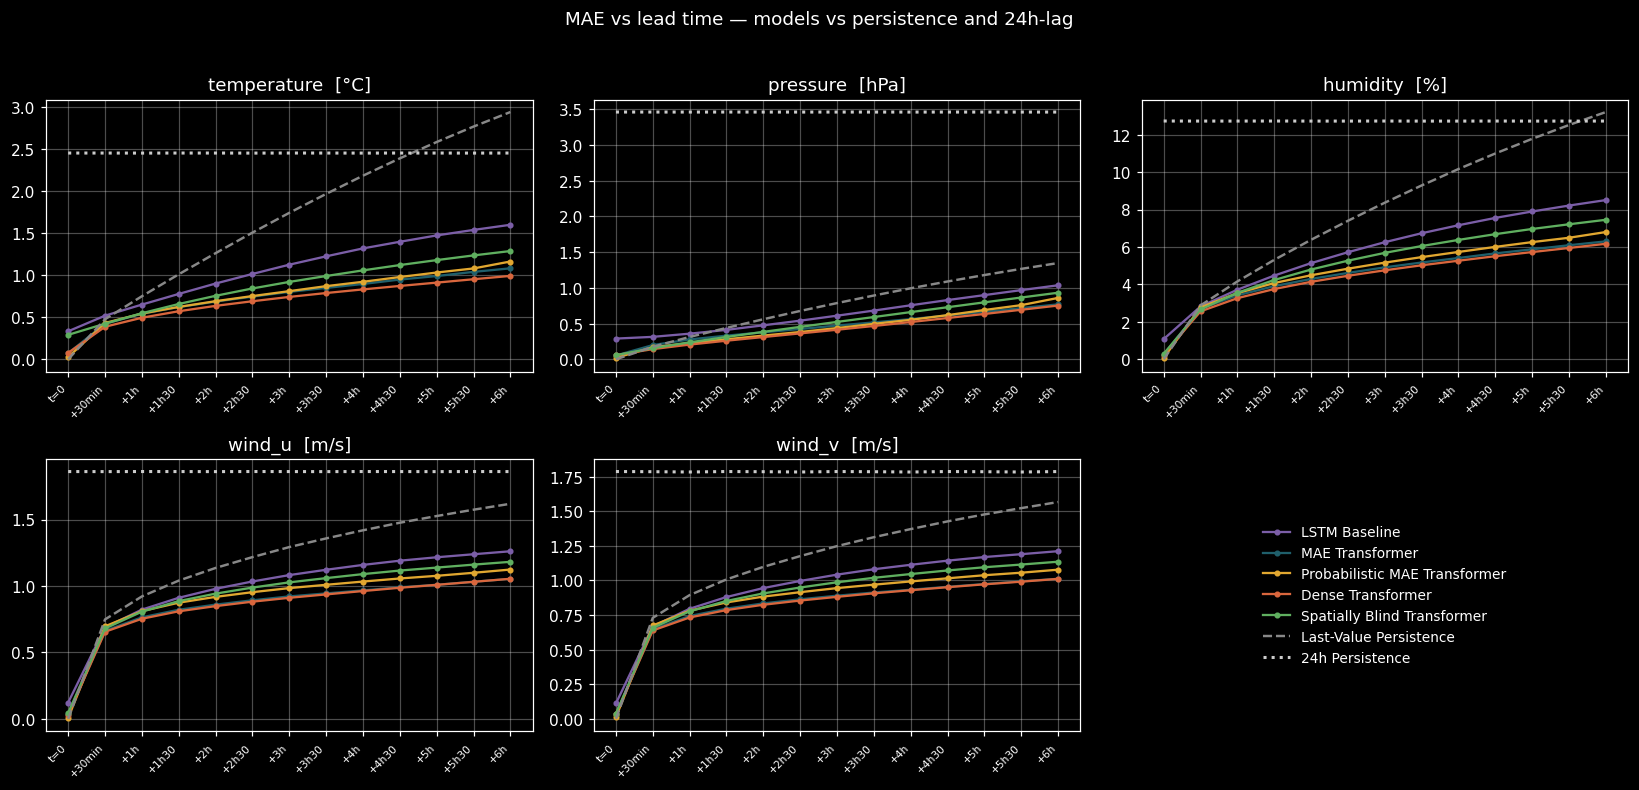

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (vi, v) in zip(axes.ravel(), enumerate(VARS)):
    for run, mr in MR0:
        a = AGG[(run, mr)]
        ax.plot(range(K), C.metric(a, "mae", pool=("N",))[:, vi], "o-",
                ms=3, lw=1.5, color=C.MODELS[run][1], label=C.MODELS[run][0])
    ax.plot(range(K), C.metric(ref, "mae", est="per",  pool=("N",))[:, vi],
            "--", color=C.BASELINE_COLORS["persistence"], lw=1.6,
            label=C.BASELINE_LABELS["persistence"])
    ax.plot(range(K), C.metric(ref, "mae", est="clim", pool=("N",))[:, vi],
            ":", color=C.BASELINE_COLORS["clim"], lw=2.0, label=C.BASELINE_LABELS["clim"])
    ax.set_xticks(range(K)); ax.set_xticklabels(LEAD, rotation=45,
                                                ha="right", fontsize=7)
    ax.set_title(f"{v}  [{C.UNITS[v]}]"); ax.grid(alpha=.3)
lax = axes.ravel()[-1]; lax.axis("off")
h, l = axes.ravel()[0].get_legend_handles_labels()
lax.legend(h, l, loc="center", fontsize=9, frameon=False)
fig.suptitle("MAE vs lead time — models vs persistence and 24h-lag", y=1.02)
plt.tight_layout(); C.save_fig(fig, "02_mae_vs_lead"); plt.show()

## 4. Skill vs lead time

Where does each model's edge over persistence come from, and does anyone beat
the 24h-lag late? Positive = beats the reference.

/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_44364/3719679548.py:9: RuntimeWarning: divide by zero encountered in divide
  ax.plot(range(1, K), (1 - mm / rr)[1:], "o-", ms=3, lw=1.4,
/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_44364/3719679548.py:9: RuntimeWarning: divide by zero encountered in divide
  ax.plot(range(1, K), (1 - mm / rr)[1:], "o-", ms=3, lw=1.4,
/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_44364/3719679548.py:9: RuntimeWarning: divide by zero encountered in divide
  ax.plot(range(1, K), (1 - mm / rr)[1:], "o-", ms=3, lw=1.4,
/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_44364/3719679548.py:9: RuntimeWarning: divide by zero encountered in divide
  ax.plot(range(1, K), (1 - mm / rr)[1:], "o-", ms=3, lw=1.4,
/var/folders/c_/b5jrks113nv2x0l4whxwz1cr0000gn/T/ipykernel_44364/3719679548.py:9: RuntimeWarning: divide by zero encountered in divide
  ax.plot(range(1, K), (1 - mm / rr)[1:], "o-", ms=3, lw=1.4,


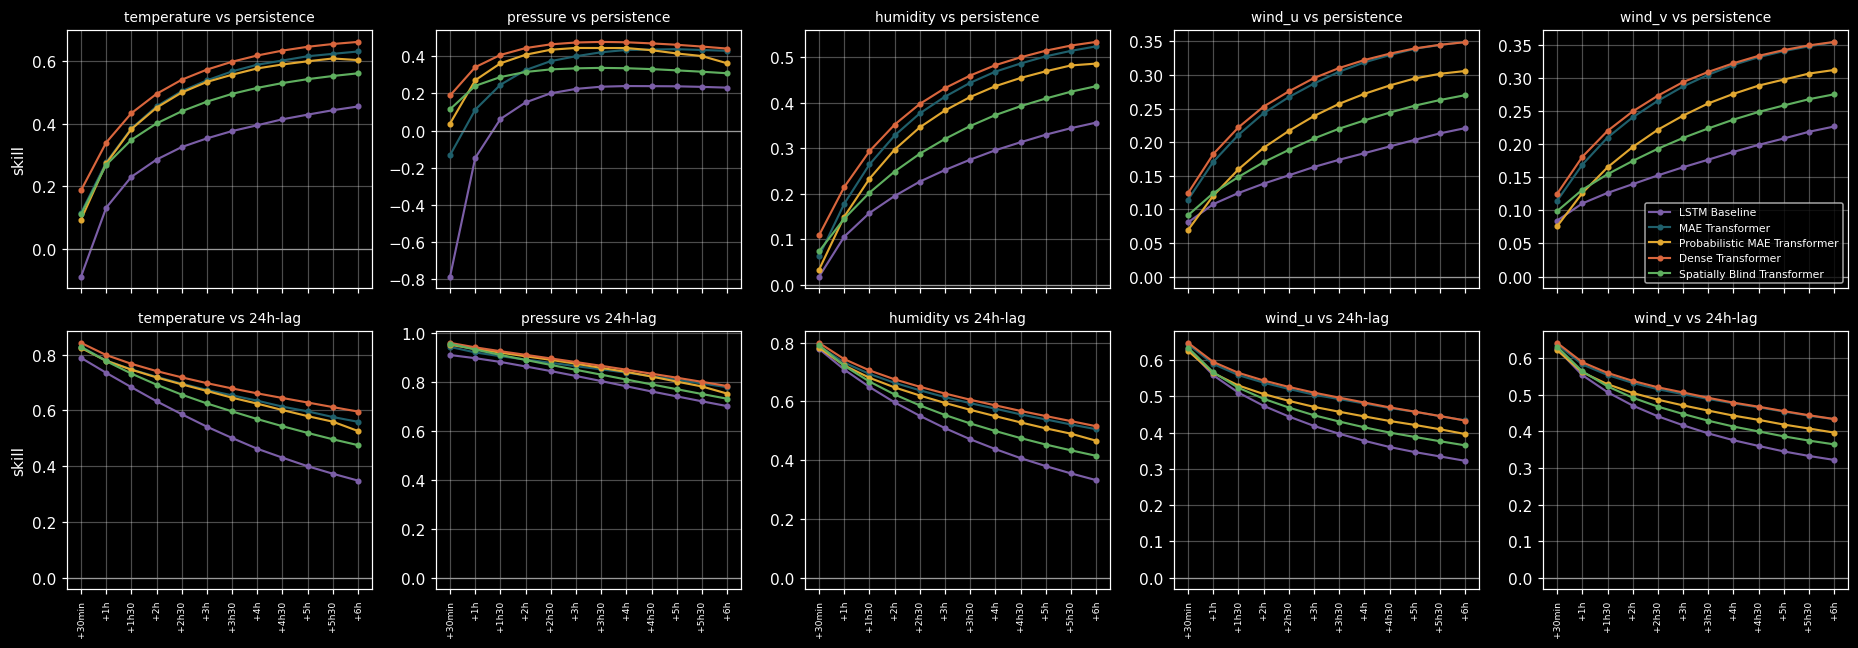

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(17, 6), sharex=True)
for row, refname in enumerate(["per", "clim"]):
    for vi, v in enumerate(VARS):
        ax = axes[row, vi]
        rr = C.metric(ref, "mae", est=refname, pool=("N",))[:, vi]
        for run, mr in MR0:
            a = AGG[(run, mr)]
            mm = C.metric(a, "mae", pool=("N",))[:, vi]
            ax.plot(range(1, K), (1 - mm / rr)[1:], "o-", ms=3, lw=1.4,
                    color=C.MODELS[run][1], label=C.MODELS[run][0])
        ax.axhline(0, color="#999", lw=.8)
        ax.set_title(f"{v} vs {'persistence' if refname=='per' else '24h-lag'}",
                     fontsize=9)
        ax.set_xticks(range(1, K))
        ax.set_xticklabels(LEAD[1:], rotation=90, fontsize=6)
        ax.grid(alpha=.3)
axes[0, 0].set_ylabel("skill"); axes[1, 0].set_ylabel("skill")
axes[0, -1].legend(fontsize=7)
plt.tight_layout(); C.save_fig(fig, "02_skill_vs_lead"); plt.show()

## Interpretation

**How to read.** Persistence must win at +30 min or the model is broken; the
question is where the model's curve crosses the baselines and how the margin
grows. Pressure: the 24h-lag will be far above persistence (synoptic
autocorrelation), so `skill_24h` is easy there — quote `skill_persist`.
Temperature/humidity: the 24h-lag becomes the harder reference by ~4-6h
(diurnal cycle); `skill_24h` at +6h is the demanding headline number.

**Observations** (fill in after running): which model leads per variable, the
size of the transformer-vs-LSTM gap, whether any model dips below zero skill
anywhere.

**Hypotheses to check downstream**: from earlier exploratory work, the
transformer's advantage over the LSTM grows with lead time (spatial context
matters more as persistence decays) — notebook 03; and station-blind v32
should trail the spatially-aware models — notebook 06.